<h1>Model Performance Comparison</h1>
<p>This script aims to compare the model performance between the logistic regression model and light GBM model built.</p>

<h2>Import Libraries</h2>
<p>Only import required and used libraries in this script - removed unused libraries</p>

In [1]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import joblib

# Graph related
import plotly.express as px
from IPython.display import Image
import matplotlib.pyplot as plt

# Machine Learning related
from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import PartialDependenceDisplay
import shap

<h2>Read Data</h2>
<p>Reading in raw data</p>

In [2]:
cwd = os.getcwd().split('amts')[0] + 'amts'
theme = "machine_learning"

In [3]:
input_folder_path = rf"{cwd}/{theme}/data/outputs/01_lgbm_introduction"

<h3>Train & Test Data</h3>

In [4]:
input_file_path = rf"{input_folder_path}/train_input_df.csv"
print(rf"Input File (Prepped Input Train Data): {input_file_path}")
train_input_df = pd.read_csv(input_file_path)

Input File (Prepped Input Train Data): c:\dev\amts/machine_learning/data/outputs/01_lgbm_introduction/train_input_df.csv


In [5]:
input_file_path = rf"{input_folder_path}/test_input_df.csv"
print(rf"Input File (Prepped Input Test Data): {input_file_path}")
test_input_df = pd.read_csv(input_file_path)

Input File (Prepped Input Test Data): c:\dev\amts/machine_learning/data/outputs/01_lgbm_introduction/test_input_df.csv


<h3>Models</h3>

In [6]:
class LogisticRegressionLoader(BaseEstimator, ClassifierMixin):
    def __init__(self, log_reg):
        self.log_reg = log_reg
        self.feature_name_ = log_reg.params.index
        self.classes_ = np.array([0,1], dtype=int)
    def fit(self, x, y):
        pass
        
    def predict_proba(self, data):
        predicted_default_flag_series = self.log_reg.predict(data)
        predicted_default_flag_series_2 = 1 - predicted_default_flag_series
        return np.column_stack((predicted_default_flag_series_2 , predicted_default_flag_series))
    
    def predict(self, data):
        predicted_default_flag_series = self.log_reg.predict(data)
        predicted_default_flag_series_2 = 1 - predicted_default_flag_series
        return np.column_stack((predicted_default_flag_series_2 , predicted_default_flag_series))
    
    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = "classifier"
        return tags

In [7]:
output_file_path = rf"{input_folder_path}/logistic_regression_model.gz"
print(rf"Input File (Logistic Regression Model): {output_file_path}")
logistic_regression_model = LogisticRegressionLoader(joblib.load(output_file_path))

Input File (Logistic Regression Model): c:\dev\amts/machine_learning/data/outputs/01_lgbm_introduction/logistic_regression_model.gz


In [8]:
output_file_path = rf"{input_folder_path}/base_light_gbm_model.gz"
print(rf"Input File (Base Light GBM Model): {output_file_path}")
base_light_gbm_model = joblib.load(output_file_path)

Input File (Base Light GBM Model): c:\dev\amts/machine_learning/data/outputs/01_lgbm_introduction/base_light_gbm_model.gz


In [9]:
output_file_path = rf"{input_folder_path}/force_overfit_light_gbm_model.gz"
print(rf"Input File (Force Overfit Light GBM Model): {output_file_path}")
force_overfit_light_gbm_model = joblib.load(output_file_path)

Input File (Force Overfit Light GBM Model): c:\dev\amts/machine_learning/data/outputs/01_lgbm_introduction/force_overfit_light_gbm_model.gz


In [10]:
output_file_path = rf"{input_folder_path}/optimised_light_gbm_model.gz"
print(rf"Input File (Optimised Light GBM Model): {output_file_path}")
optimised_light_gbm_model = joblib.load(output_file_path)

Input File (Optimised Light GBM Model): c:\dev\amts/machine_learning/data/outputs/01_lgbm_introduction/optimised_light_gbm_model.gz


<h2>Model Performance Comparison</h2>

In [11]:
print('\n---Start Model Performance Comparison---')


---Start Model Performance Comparison---


<h3>Get predictions</h3>

In [12]:
all_models_dict = {
    'logistic_regression': logistic_regression_model, 
    'base_light_gbm': base_light_gbm_model, 
    'force_overfit_light_gbm': force_overfit_light_gbm_model, 
    'optimised_light_gbm': optimised_light_gbm_model, 
}

In [13]:
def get_predictions_for_all_models(input_df: pd.DataFrame, all_models: dict):
    output_df = input_df.copy()
    for model_name, model_object in all_models.items():
        output_df = sm.add_constant(output_df)
        output_df[f'predicted_default_flag_{model_name}'] = model_object.predict_proba(output_df[model_object.feature_name_])[:, 1]
    return output_df

In [14]:
train_with_predictions_df = get_predictions_for_all_models(train_input_df, all_models_dict)
test_with_predictions_df = get_predictions_for_all_models(test_input_df, all_models_dict)

<h3>Compare Gini</h3>

In [15]:
print('\n--Gini--')


--Gini--


<h4>Define all utils functions</h4>

<h5>Calculate Gini</h5>

In [16]:
def calculate_gini(input_df: pd.DataFrame, weights_column_str: str = None):
    melted_input_df = pd.melt(input_df, id_vars=['actual_default_flag'], var_name='model_type', value_name='predicted_default_flag', value_vars=[f'predicted_default_flag_{i}' for i in all_models_dict])
    
    weights = weights_column_str if weights_column_str is None else melted_input_df[weights_column_str]
    auc_by_models_output_dict = {
        model_name[0].replace('predicted_default_flag_', ''): [roc_auc_score(model_group['actual_default_flag'], model_group['predicted_default_flag'], sample_weight=weights)]
        for model_name, model_group in melted_input_df.groupby(['model_type'])
    }
    output_df = pd.DataFrame.from_dict(auc_by_models_output_dict, orient='index', columns=['auc']).reset_index(names=['model_type'])
    
    output_df['gini'] = (output_df['auc'] - 0.5) * 2
    output_df.drop(columns=['auc'], inplace=True)
    return output_df

<h4>Get Gini results by models</h4>

<h5>Calculate Gini</h5>

In [17]:
train_with_gini_df = calculate_gini(train_with_predictions_df)
test_with_gini_df = calculate_gini(test_with_predictions_df)

<h5>Combine results</h5>

In [18]:
train_with_gini_df['data_type'] = 'train'
test_with_gini_df['data_type'] = 'test'

gini_df = pd.concat([train_with_gini_df, test_with_gini_df], axis=0)

<h5>Plot results</h5>

In [19]:
fig = px.histogram(
    gini_df,
    title='Gini',
    x='model_type',
    y='gini',
    color='data_type',
    barmode='group',
    template='none',
    text_auto=True,
    width=700,
    height=400
)

fig.update_layout(autosize=True, font_size=10)
fig.update_xaxes(automargin=True)
fig.update_yaxes(automargin=True, title='Gini', range=[0, 1], tickformat='.1%')
fig.update_traces(textposition='inside')
Image(fig.to_image('png'))
fig.show()

<h3>Compare Actual vs Predicted Default Rate</h3>

In [20]:
print('\n--Actual vs Predicted Default Rate--')


--Actual vs Predicted Default Rate--


<h4>Define all utils functions</h4>

<h5>Aggregate results by bins</h5>

In [21]:
def group_results_by_bins(input_df: pd.DataFrame, variables_to_bin_list: list, qcut_flag: bool, qcut_bin_number_int: int = 1, cut_bins_dict: dict = {}):
    result_variables_list = [i for i in input_df.columns if 'default_flag' in i]

    output_df = input_df.copy()
    
    for variable_str in variables_to_bin_list:
        # Create bins depending if qcut (quintile cut) is selected
        if qcut_flag: 
            output_df[f'{variable_str}_bin'] = pd.arrays.IntervalArray(pd.qcut(output_df[variable_str], qcut_bin_number_int)).left
        else: 
            output_df[f'{variable_str}_bin'] = pd.arrays.IntervalArray(pd.cut(output_df[variable_str], cut_bins_dict[variable_str])).left

        # Rename bins to be ordered
        bin_names_mapping_dict = {
            original_bin_name: f'{i + 1:02d}:{original_bin_name}'
            for i, original_bin_name in enumerate(output_df[f'{variable_str}_bin'].sort_values().unique())
        }
        output_df[f'{variable_str}_bin'] = output_df[f'{variable_str}_bin'].map(bin_names_mapping_dict)

    binned_variables_list = [f'{col}_bin' for col in variables_to_bin_list]
    output_df = output_df.groupby(binned_variables_list)[result_variables_list].agg('mean').reset_index()
    return output_df

<h5>Plot results by bins</h5>

In [22]:
def plot_results_by_bins(input_df: pd.DataFrame, title_str: str, variables_to_bin_list: list):
    binned_variables_list = [f'{col}_bin' for col in variables_to_bin_list]
    result_variables_list = [i for i in input_df.columns if 'default_flag' in i]
    
    if len(binned_variables_list) == 1: 
        fig = px.line(
            input_df,
            title=title_str,
            x=binned_variables_list[0],
            y=result_variables_list,
            template='none',
            width=700,
            height=400
        )
    else: 
        fig = px.line(
            input_df,
            title=title_str,
            facet_col=binned_variables_list[0],
            facet_col_wrap=2,
            x=binned_variables_list[1],
            y=result_variables_list,
            template='none',
            facet_row_spacing=0.1,
            facet_col_spacing=0.1,
            width=1000,
            height=600
        )

    fig.update_layout(autosize=True, font_size=10, legend=dict(y=0.5, font=dict(size=8), title='Model Type'))
    fig.update_xaxes(automargin=True)
    fig.update_yaxes(automargin=True, title='Default', matches=None, showticklabels=True)
    fig.update_traces(patch={'line':{'dash':'dash', 'width':3}})
    fig.update_traces(patch={'line':{'dash':'solid', 'color':'black', 'width':2}}, selector={'name':'actual_default_flag'})
    Image(fig.to_image('png'))
    fig.show()

<h5>Filter accounts by days past due</h5>

In [23]:
def filter_accounts_by_dpd(input_df: pd.DataFrame, dpd_threshold: int):
    output_df = input_df[input_df['days_past_due'] < dpd_threshold]
    return output_df

<h4>Define generic variables</h4>

In [24]:
features_to_cut_bins_mapping_dict = {
    'credit_limit' : [float("-inf"), 600, float("+inf")],
    'external_score' : [float("-inf"), 200, 500, 800, float("+inf")],
    'days_past_due' : [float("-inf"), 5, 15, 30, 60, float("+inf")],
}

<h4>Get variables results by bins</h4>

<h5>Credit limit</h5>

In [25]:
variables_to_bin_list = ['credit_limit']

chart_input_df = group_results_by_bins(input_df=test_with_predictions_df, variables_to_bin_list=variables_to_bin_list, qcut_flag=True, qcut_bin_number_int=4)
plot_results_by_bins(chart_input_df, f'Test Data: Actual vs Predicted Default of {variables_to_bin_list[0]}', variables_to_bin_list)

<h5>Balance</h5>

In [26]:
variables_to_bin_list = ['balance']

chart_input_df = filter_accounts_by_dpd(test_with_predictions_df, 10)
chart_input_df = group_results_by_bins(input_df=chart_input_df, variables_to_bin_list=variables_to_bin_list, qcut_flag=True, qcut_bin_number_int=5)
plot_results_by_bins(chart_input_df, f'Test Data: Actual vs Predicted Default of {variables_to_bin_list[0]}', variables_to_bin_list)

<h5>Days past due</h5>

In [27]:
variables_to_bin_list = ['days_past_due']

chart_input_df = group_results_by_bins(input_df=test_with_predictions_df, variables_to_bin_list=variables_to_bin_list, qcut_flag=False, cut_bins_dict=features_to_cut_bins_mapping_dict)
plot_results_by_bins(chart_input_df, f'Test Data: Actual vs Predicted Default of {variables_to_bin_list[0]}', variables_to_bin_list)

<h5>External score</h5>

In [28]:
variables_to_bin_list = ['external_score']

chart_input_df = group_results_by_bins(input_df=test_with_predictions_df, variables_to_bin_list=variables_to_bin_list, qcut_flag=False, cut_bins_dict=features_to_cut_bins_mapping_dict)
plot_results_by_bins(chart_input_df, f'Test Data: Actual vs Predicted Default of {variables_to_bin_list[0]}', variables_to_bin_list)

<h5>External score and credit limit</h5>

In [29]:
variables_to_bin_list = ['external_score', 'credit_limit']

chart_input_df = group_results_by_bins(input_df=test_with_predictions_df, variables_to_bin_list=variables_to_bin_list, qcut_flag=False, cut_bins_dict=features_to_cut_bins_mapping_dict)
plot_results_by_bins(chart_input_df, f'Test Data: Actual vs Predicted Default of {variables_to_bin_list[0]} against {variables_to_bin_list[1]}', variables_to_bin_list)

<h3>Compare Scores Distribution</h3>

In [30]:
print('\n--Scores Distribution--')


--Scores Distribution--


<h4>Define all utils functions</h4>

<h5>Calculate scores</h5>

In [31]:
def calculate_score(input_df: pd.DataFrame):
    output_df = input_df.copy()

    predicted_default_flag_variables_list = [x for x in input_df.columns if 'predicted_default_flag' in x]
    score_variables_list = [x.replace('predicted_default_flag', 'score') for x in input_df.columns if 'predicted_default_flag' in x]

    output_df[score_variables_list] = np.round(
        500 - 20 / np.log(2) * np.log(output_df[predicted_default_flag_variables_list] / (1 - output_df[predicted_default_flag_variables_list]))
        , 0)
    return output_df

<h5>Create score bins</h5>

In [32]:
def create_score_bins(input_df: pd.DataFrame, arbitrary_bin_groups: int, percentile_bin_groups: int):
    output_df = input_df.copy()
    
    score_variables_list = [x.replace('predicted_default_flag', 'score') for x in input_df.columns if 'predicted_default_flag' in x]

    score_bin_variables_list = [x.replace('score', 'score_bin') for x in score_variables_list]
    grouper = 1000 / arbitrary_bin_groups
    output_df[score_bin_variables_list] = (output_df[score_variables_list] / grouper).astype('int') * grouper

    score_percentile_bin_variables_list = [x.replace('score', 'score_percentile_bin') for x in score_variables_list]
    output_df[score_percentile_bin_variables_list] = pd.Series([
        pd.qcut(output_df[var], percentile_bin_groups, labels=False, duplicates='drop')
        for var in score_variables_list
    ])
    return output_df

<h5>Plot lift charts</h5>

In [33]:
def plot_lift_charts(input_df: pd.DataFrame, title_str: str): 
    score_percentile_bin_variables_list = [x.replace('predicted_default_flag', 'score_percentile_bin') for x in input_df.columns if 'predicted_default_flag' in x]
    melted_input_df = pd.melt(input_df, id_vars=['actual_default_flag'], var_name='model_type', value_name='score_percentile_bin', value_vars=score_percentile_bin_variables_list)
    chart_input_df = melted_input_df.groupby(['model_type', 'score_percentile_bin'])['actual_default_flag'].mean().reset_index()
    chart_input_df['model_type'] = chart_input_df['model_type'].str.replace('score_percentile_bin_', '')
    
    fig = px.line(
        chart_input_df,
        title=title_str,
        x='score_percentile_bin',
        y='actual_default_flag',
        template='none',
        color='model_type',
        width=700,
        height=400
    )
    
    fig.update_layout(autosize=True, font_size=10, legend=dict(y=0.5, font=dict(size=8), title='Model Type'))
    fig.update_xaxes(automargin=True, dtick=1)
    fig.update_yaxes(automargin=True, title='Default', range=[0, 1])
    Image(fig.to_image('png'))
    fig.show()    

<h5>Plot scores migration</h5>

In [34]:
def plot_score_migration(input_df: pd.DataFrame, title_str: str, groupby_variables_list: list):
    chart_input_df = input_df.groupby(groupby_variables_list)['external_score'].count().reset_index(name='count')

    fig = px.scatter(
        chart_input_df, 
        x=groupby_variables_list[0],
        y=groupby_variables_list[1],
        title=title_str,
        size='count',
        size_max=50,
        color='count',
        color_continuous_scale=px.colors.sequential.Viridis_r,
        template='none',
        width=700,
        height=400
    )

    fig.add_shape(
        type='line',
        xref='paper',
        yref='paper',
        x0=0, y0=0,
        x1=1, y1=1,
        line={'color':'grey', 'width':2, 'dash':'dash'}
    )

    fig.update_layout(autosize=True, font_size=10)
    fig.update_xaxes(automargin=True)
    fig.update_yaxes(automargin=True)
    Image(fig.to_image('png'))
    fig.show()

<h4>Get variables' scores results</h4>

<h5>Train data</h5>

In [35]:
train_with_score_df = calculate_score(train_with_predictions_df)
train_with_binned_score_df = create_score_bins(train_with_score_df, 50, 4)

In [36]:
plot_lift_charts(train_with_binned_score_df, 'Train Data: Lift Chart (Actual Default Rate by Percentiles)')

In [37]:
groupby_variables_list = ['score_bin_optimised_light_gbm', 'score_bin_logistic_regression']

plot_score_migration(train_with_binned_score_df, 'Train Data: Score Migration', groupby_variables_list)

<h5>Test data</h5>

In [38]:
test_with_score_df = calculate_score(test_with_predictions_df)
test_with_binned_score_df = create_score_bins(test_with_score_df, 50, 4)

In [39]:
plot_lift_charts(test_with_binned_score_df, 'Test Data: Lift Chart (Actual Default Rate by Percentiles)')

In [40]:
groupby_variables_list = ['score_bin_optimised_light_gbm', 'score_bin_logistic_regression']

plot_score_migration(test_with_binned_score_df, 'Test Data: Score Migration', groupby_variables_list)

<h3>Compare SHAP</h3>

In [41]:
print('\n--SHAP--')


--SHAP--


<h4>Define all utils functions</h4>

<h5>Setup SHAP class</h5>

In [42]:
class ApplyShap:
    def __init__(self, model, data, title_prefix):
        self.model = model
        self.data = sm.add_constant(data)
        self.data = self.data[model.feature_name_]
        self.title_prefix = title_prefix
    
    def calculate_shap(self):
        try:
            self.explainer = shap.TreeExplainer(self.model, self.data)
        except:
            self.explainer = shap.KernelExplainer(self.model.predict_proba, self.data)
    
        self.shap_values = self.explainer(self.data)
    
    def plot_beeswarm(self, max_display=20, log_scale=False):
        try:
            shap.plots.beeswarm(self.shap_values, max_display=max_display, log_scale=log_scale, show=False)
        except:
            shap.plots.beeswarm(self.shap_values[:, :, 1], max_display=max_display, log_scale=log_scale, show=False)

        fig, ax = plt.gcf(), plt.gca()
        ax.set_title(f'{self.title_prefix}: Beeswarm')
        plt.show()

    def plot_partial_dependence(self, col_names: list):
        fig, ax = plt.subplots(figsize=(14, 2.5))
        if len(col_names) <= 1:
            col_list = col_names
        else:
            col_list = [col_names[0], col_names[1], (col_names[0], col_names[1])]
        PartialDependenceDisplay.from_estimator(self.model, self.data, col_list, ax=ax)
        fig.suptitle(f'{self.title_prefix}: Partial Dependence')

<h4>Get SHAP results by models</h4>

<h5>Logistic regression</h5>

In [43]:
print('--Logistic Regression--')

--Logistic Regression--


In [44]:
all_models_dict['logistic_regression'].dummy_ = None
logistic_regression_shap = ApplyShap(all_models_dict['logistic_regression'], test_input_df, 'Test Data')
logistic_regression_shap.calculate_shap()

Using 1425 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1425 [00:00<?, ?it/s]

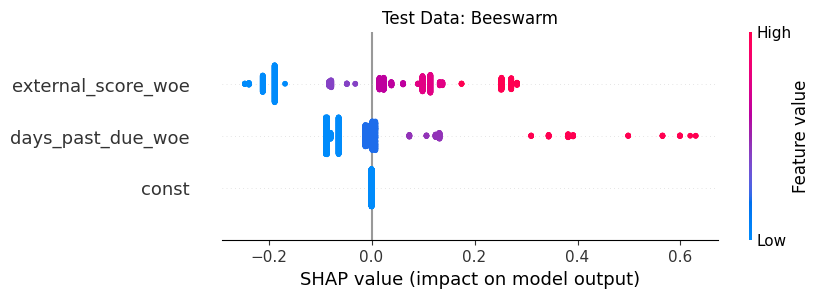

In [45]:
logistic_regression_shap.plot_beeswarm()

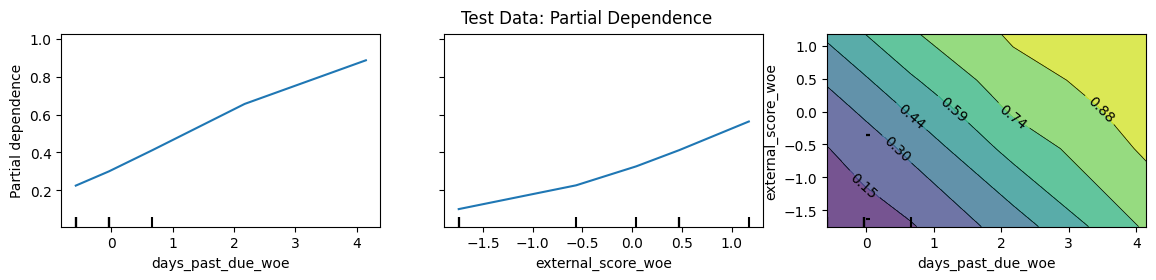

In [46]:
logistic_regression_shap.plot_partial_dependence(['days_past_due_woe', 'external_score_woe'])

<h5>Optimised Light GBM</h5>

In [47]:
print('\n--Optimised Light GBM--')


--Optimised Light GBM--


In [48]:
optimised_light_gbm_shap = ApplyShap(all_models_dict['optimised_light_gbm'], test_input_df, 'Test Data')
optimised_light_gbm_shap.calculate_shap()

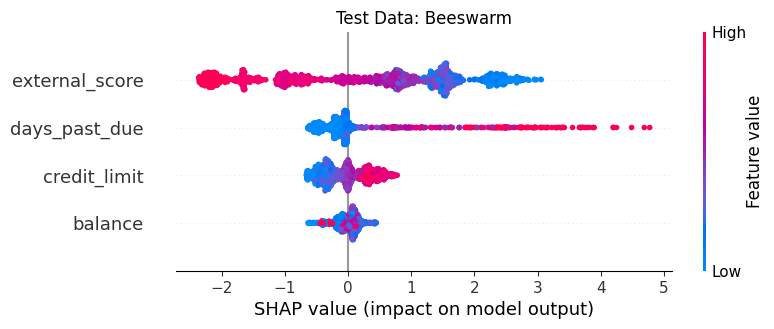

In [49]:
optimised_light_gbm_shap.plot_beeswarm()

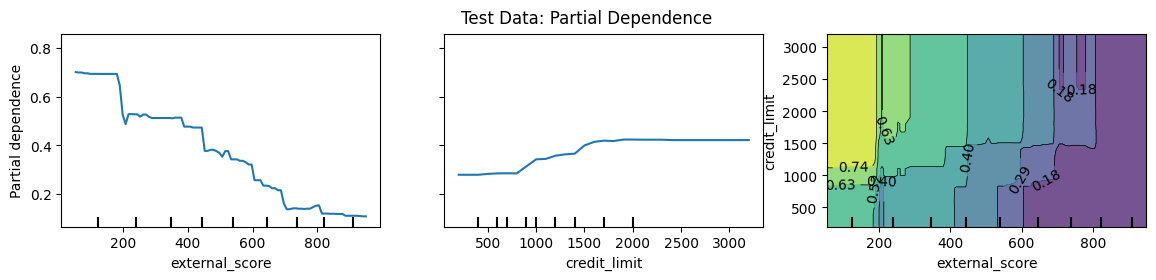

In [50]:
optimised_light_gbm_shap.plot_partial_dependence(['external_score','credit_limit'])